============================================================
DELHI AQI - COMPLETE REVISED CODE
Run top to bottom after kernel restart
============================================================

============================================================
CELL 1: IMPORTS
============================================================

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

============================================================
CELL 2: LOAD DATA
============================================================

In [29]:
df = pd.read_csv('final_dataset.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (1461, 12)
Columns: ['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI']
   Date  Month  Year  Holidays_Count  Days   PM2.5    PM10     NO2    SO2  \
0     1      1  2021               0     5  408.80  442.42  160.61  12.95   
1     2      1  2021               0     6  404.04  561.95   52.85   5.18   
2     3      1  2021               1     7  225.07  239.04  170.95  10.93   
3     4      1  2021               0     1   89.55  132.08  153.98  10.42   
4     5      1  2021               0     2   54.06   55.54  122.66   9.70   

     CO  Ozone  AQI  
0  2.77  43.19  462  
1  2.60  16.43  482  
2  1.40  44.29  263  
3  1.01  49.19  207  
4  0.64  48.88  149  


============================================================
CELL 3: DATA INFO & MISSING VALUES
============================================================

In [30]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
# Data provenance note:
# Dataset: 1,461 daily observations, Jan 2021 - Dec 2024
# Source: Kaggle (Bhatia, 2024), compiled from Delhi air quality monitoring
# Columns include calendar features (Holidays_Count, Days/weekday)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1461 non-null   int64  
 1   Month           1461 non-null   int64  
 2   Year            1461 non-null   int64  
 3   Holidays_Count  1461 non-null   int64  
 4   Days            1461 non-null   int64  
 5   PM2.5           1461 non-null   float64
 6   PM10            1461 non-null   float64
 7   NO2             1461 non-null   float64
 8   SO2             1461 non-null   float64
 9   CO              1461 non-null   float64
 10  Ozone           1461 non-null   float64
 11  AQI             1461 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 137.1 KB

Missing values:
 Date              0
Month             0
Year              0
Holidays_Count    0
Days              0
PM2.5             0
PM10              0
NO2               0
SO2               0
CO           

============================================================
CELL 4: STATISTICAL SUMMARY
============================================================

In [31]:
print(df.describe())

              Date        Month         Year  Holidays_Count         Days  \
count  1461.000000  1461.000000  1461.000000     1461.000000  1461.000000   
mean     15.729637     6.522930  2022.501027        0.189596     4.000684   
std       8.803105     3.449884     1.118723        0.392116     2.001883   
min       1.000000     1.000000  2021.000000        0.000000     1.000000   
25%       8.000000     4.000000  2022.000000        0.000000     2.000000   
50%      16.000000     7.000000  2023.000000        0.000000     4.000000   
75%      23.000000    10.000000  2024.000000        0.000000     6.000000   
max      31.000000    12.000000  2024.000000        1.000000     7.000000   

             PM2.5         PM10          NO2          SO2           CO  \
count  1461.000000  1461.000000  1461.000000  1461.000000  1461.000000   
mean     90.774538   218.219261    37.184921    20.104921     1.025832   
std      71.650579   129.297734    35.225327    16.543659     0.608305   
min       

============================================================
CELL 5: CORRELATION MATRIX
============================================================

In [32]:
print(df.corr(numeric_only=True))

                    Date     Month      Year  Holidays_Count      Days  \
Date            1.000000  0.010522  0.001384        0.019424  0.001487   
Month           0.010522  1.000000 -0.001204        0.002100  0.002824   
Year            0.001384 -0.001204  1.000000        0.008144 -0.002600   
Holidays_Count  0.019424  0.002100  0.008144        1.000000  0.514644   
Days            0.001487  0.002824 -0.002600        0.514644  1.000000   
PM2.5           0.020023 -0.074140 -0.254641       -0.008869  0.006395   
PM10            0.011082  0.046479  0.034936       -0.016789 -0.024105   
NO2             0.008788  0.082342 -0.078301       -0.005577  0.018301   
SO2             0.044515  0.142763  0.612480        0.008760 -0.009367   
CO              0.033665  0.081195 -0.202139       -0.003863  0.000779   
Ozone          -0.010748 -0.102716  0.092638        0.007388  0.022247   
AQI            -0.001057 -0.034169 -0.083563        0.000447  0.002113   

                   PM2.5      PM10   

# ============================================================
# CELL 6: CORRELATION HEATMAP
# ============================================================

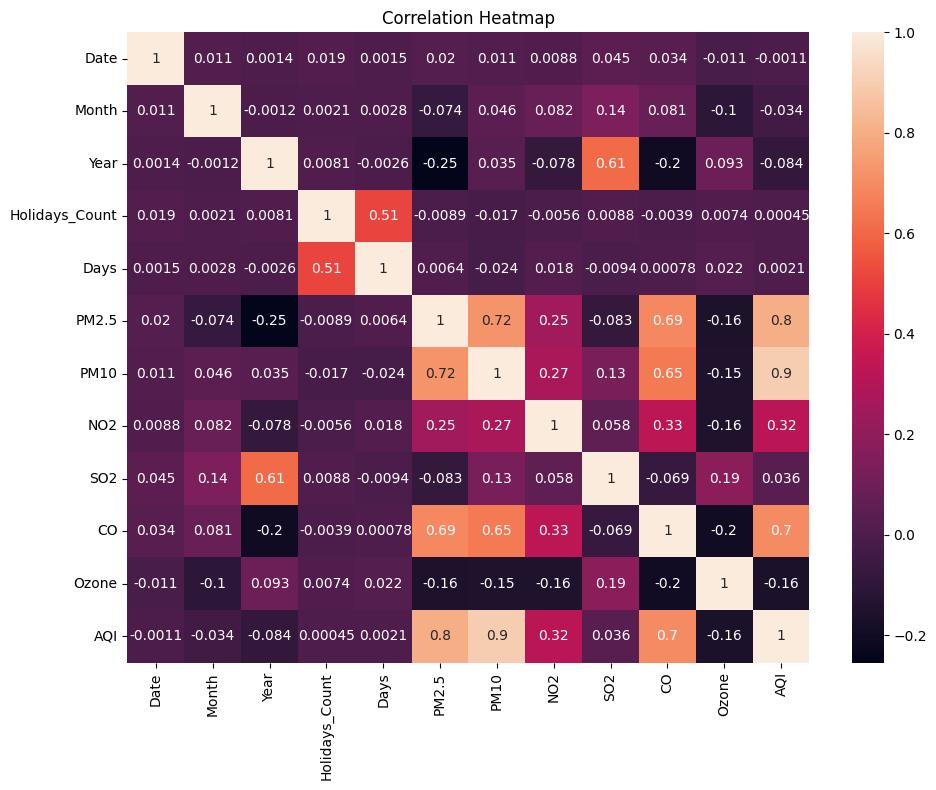

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()


# ============================================================
# CELL 7: SCATTER PLOTS - EACH POLLUTANT VS AQI
# ============================================================

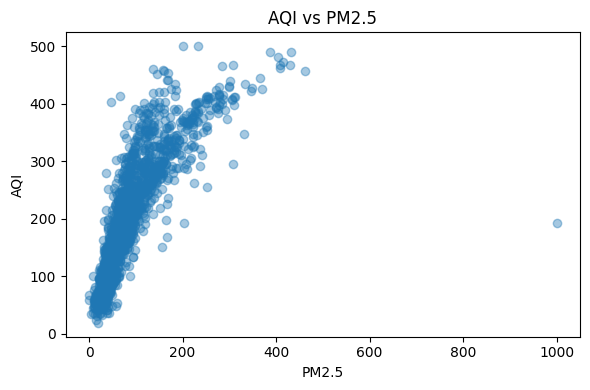

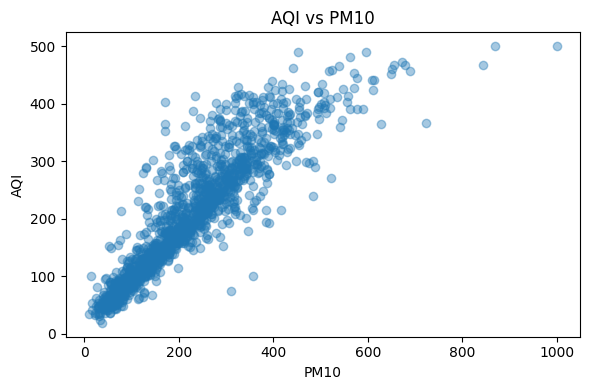

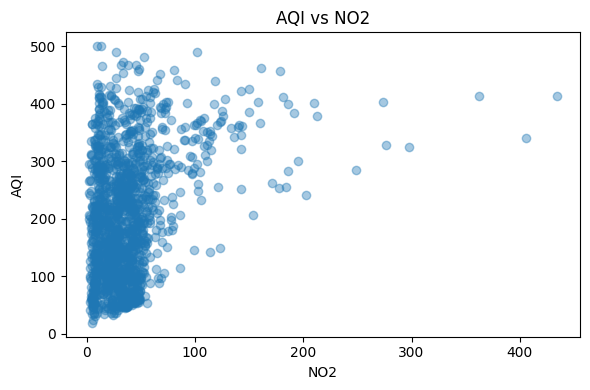

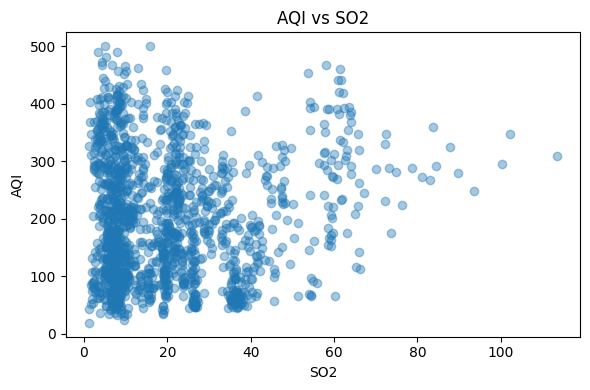

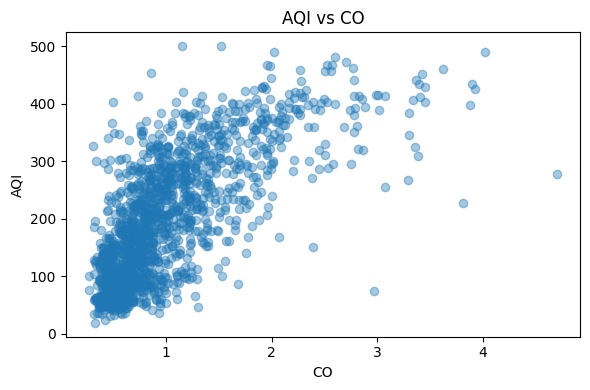

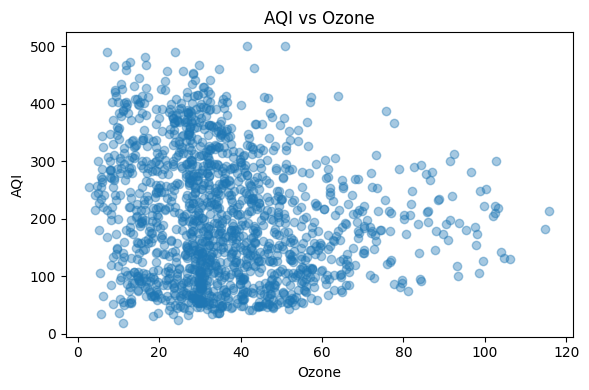

In [34]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']

for col in pollutants:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df[col], df['AQI'], alpha=0.4)
    ax.set_xlabel(col)
    ax.set_ylabel('AQI')
    ax.set_title(f'AQI vs {col}')
    plt.tight_layout()
    plt.show()

# ============================================================
# CELL 8: AQI OVER TIME
# ============================================================


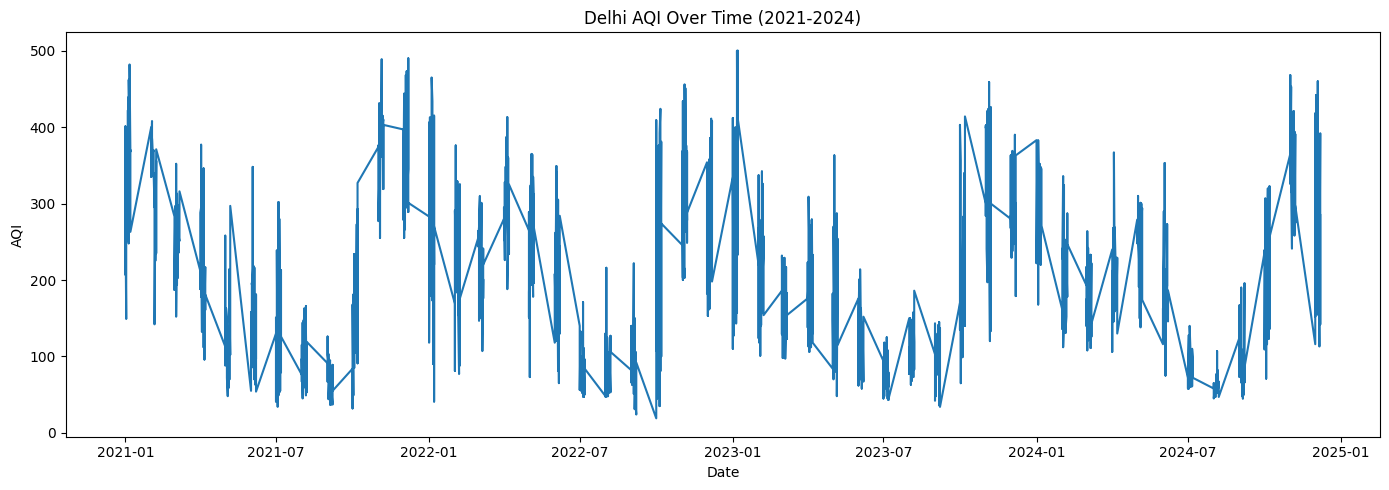

In [35]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Days']]
                            .rename(columns={'Days': 'day'}))
df = df.sort_values('Date').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'], df['AQI'])
ax.set_title('Delhi AQI Over Time (2021-2024)')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
plt.tight_layout()
plt.show()

In [36]:
# Create lagged features (Issue #17)
lag_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']
for lag in [1, 2, 3, 7]:
    for col in lag_cols:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

df = df.dropna().reset_index(drop=True)
df.to_csv('final_dataset_lagged.csv', index=False)
print("Lagged dataset saved. Shape:", df.shape)

Lagged dataset saved. Shape: (1454, 36)


In [37]:
# VIF on lagged features (Issue #17 + #14)
X_vif_lagged = df[[c for c in df.columns if 'lag' in c]]
vif_lagged = pd.DataFrame()
vif_lagged["Feature"] = X_vif_lagged.columns
vif_lagged["VIF"] = [variance_inflation_factor(X_vif_lagged.values, i)
                     for i in range(X_vif_lagged.shape[1])]
print("VIF Analysis (Lagged Features):")
print(vif_lagged.sort_values("VIF", ascending=False))

VIF Analysis (Lagged Features):
       Feature        VIF
19   PM10_lag7  14.592676
13   PM10_lag3  14.385919
7    PM10_lag2  14.043758
1    PM10_lag1  13.932084
9     SO2_lag2  10.646123
15    SO2_lag3  10.327396
18  PM2.5_lag7  10.136724
16     CO_lag3  10.083296
22     CO_lag7  10.053326
4      CO_lag1   9.875100
10     CO_lag2   9.859295
0   PM2.5_lag1   9.765078
12  PM2.5_lag3   9.703670
6   PM2.5_lag2   9.693684
21    SO2_lag7   9.361779
3     SO2_lag1   9.199708
23  Ozone_lag7   6.835394
11  Ozone_lag2   6.234885
17  Ozone_lag3   6.218742
5   Ozone_lag1   6.159994
14    NO2_lag3   3.564976
20    NO2_lag7   3.536111
8     NO2_lag2   3.498727
2     NO2_lag1   3.249521


# ============================================================
# CELL 9: AQI BY MONTH - BOX PLOT
# ============================================================

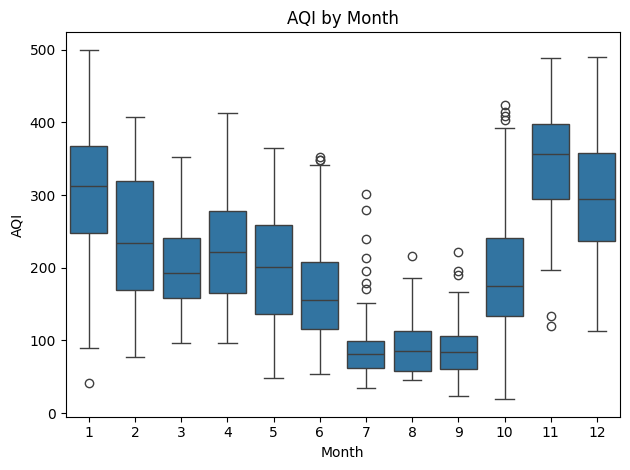

In [38]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Month', y='AQI', ax=ax)
ax.set_title('AQI by Month')
plt.tight_layout()
plt.show()


============================================================
CELL 10: VIF ANALYSIS (Issue #14 - multicollinearity)
============================================================

In [39]:
X_vif = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone']]
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]
print("VIF Analysis:")
print(vif_data.sort_values("VIF", ascending=False))

VIF Analysis:
  Feature       VIF
1    PM10  9.439772
4      CO  7.788382
0   PM2.5  6.884702
5   Ozone  2.843510
3     SO2  2.746406
2     NO2  2.380540


============================================================
CELL 11: SEASONAL DECOMPOSITION (Issue #13)
============================================================

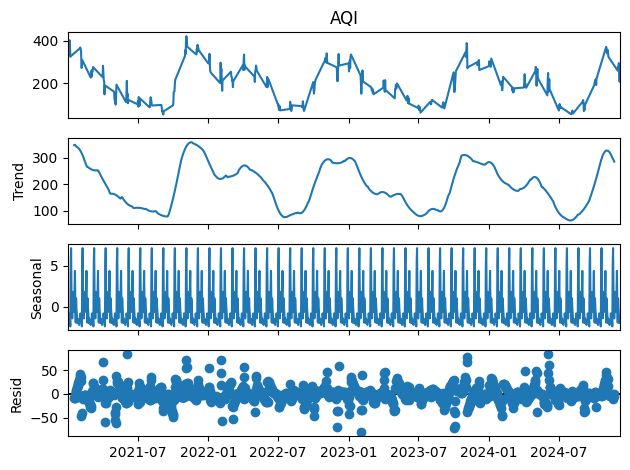

In [40]:
aqi_series = df.groupby('Date')['AQI'].mean()
aqi_series = aqi_series.asfreq('D').interpolate()
decomp = seasonal_decompose(aqi_series, model='additive', period=30)
decomp.plot()
plt.tight_layout()
plt.show()